# UFO Sightings
Name: MDMS Wickramasinghe /
Module Code: 4FTC2113 /
Student ID: 25000327


# Importing dataset libararies


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA




In [57]:

df = pd.read_csv('complete.csv', engine='python', on_bad_lines='skip')
print("Initial dataset shape:", df.shape)
df.head()


Initial dataset shape: (88679, 11)


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


## Data Preprocessing

Before applying clustering, the dataset was cleaned to ensure that only valid and meaningful observations were used. This step is essential for distance-based algorithms such as K-Means, which are sensitive to outliers, invalid values, and scale differences.


In [60]:
df.isnull().sum()

datetime                    0
city                        0
state                    7189
country                 12043
shape                    2660
duration (seconds)          2
duration (hours/min)     2639
comments                   30
date posted                 0
latitude                    0
longitude                   0
year                        0
month                       0
hour                        0
dtype: int64

In [62]:
df = df.dropna(subset=['duration (seconds)'])
df = df.rename(columns={'duration (seconds)': 'duration_seconds'})


In [63]:
df['shape'] = df['shape'].fillna('Unknown')


In [64]:
print(df.shape)


(87457, 14)


In [65]:
# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['datetime'])

# Extract time features
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

print("After datetime cleaning:", df.shape)



After datetime cleaning: (87457, 14)


In [66]:
# Convert duration to numeric
df['duration_seconds'] = pd.to_numeric(df['duration_seconds'], errors='coerce')

# Remove invalid durations
df = df.dropna(subset=['duration_seconds'])

# Remove unrealistic values
df = df[(df['duration_seconds'] > 0) & (df['duration_seconds'] < 86400)]

print("After duration cleaning:", df.shape)


After duration cleaning: (80720, 14)


In [67]:
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180))
]

print("After geographic cleaning:", df.shape)


After geographic cleaning: (80719, 14)


# Visualizations

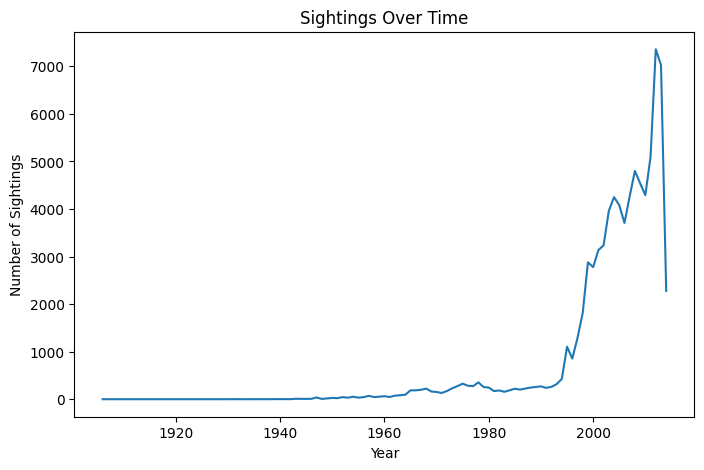

In [68]:
plt.figure(figsize=(8,5))
df['year'].value_counts().sort_index().plot()
plt.title("Sightings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Sightings")
plt.show()


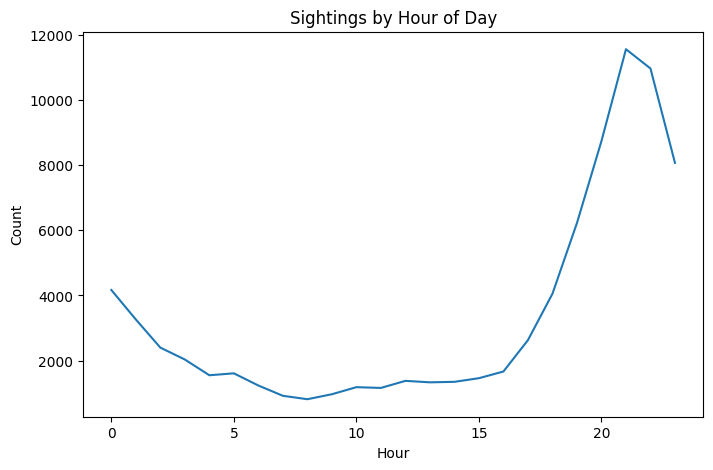

In [69]:
plt.figure(figsize=(8,5))
df['hour'].value_counts().sort_index().plot()
plt.title("Sightings by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


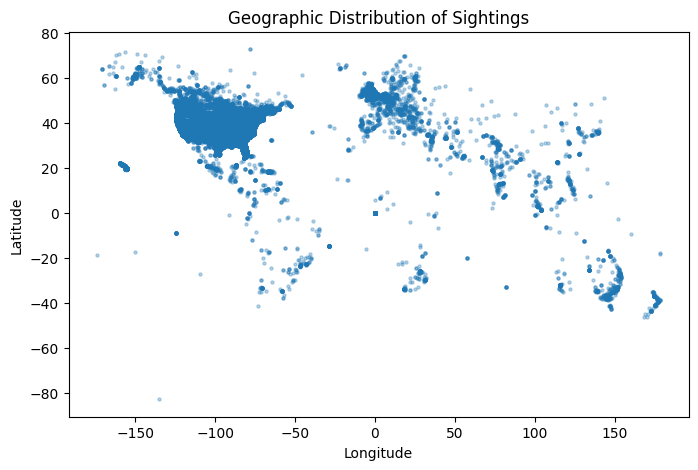

In [70]:
plt.figure(figsize=(8,5))
plt.scatter(df['longitude'], df['latitude'], alpha=0.3, s=5)
plt.title("Geographic Distribution of Sightings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [71]:
features = df[['latitude', 'longitude', 'year', 'hour', 'duration_seconds']]


## Feature Scaling

K-Means clustering relies on Euclidean distance to assign observations to clusters. Since the selected features (e.g., duration, latitude, year) exist on different numeric scales, standardisation was applied using `StandardScaler` to make sure that no single feature dominated the distance calculations.


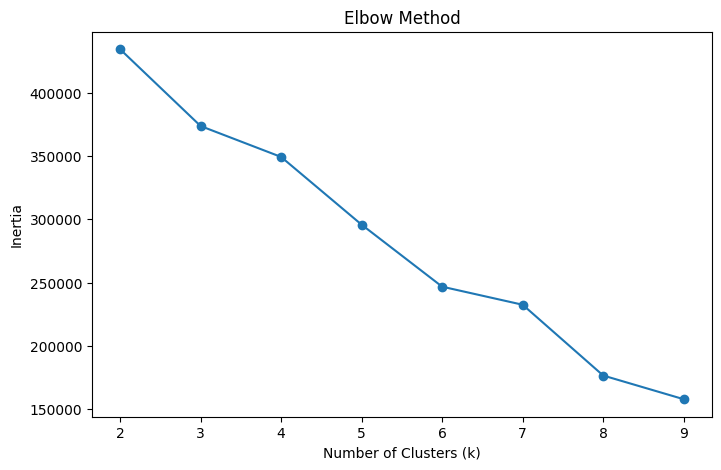

In [72]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


## Determining the Optimal Number of Clusters

Selecting an appropriate number of clusters is critical for meaningful clustering. To objectively evaluate different values of k, silhouette analysis was used. The silhouette score measures both cluster cohesion and separation, with higher values indicating better-defined clusters.


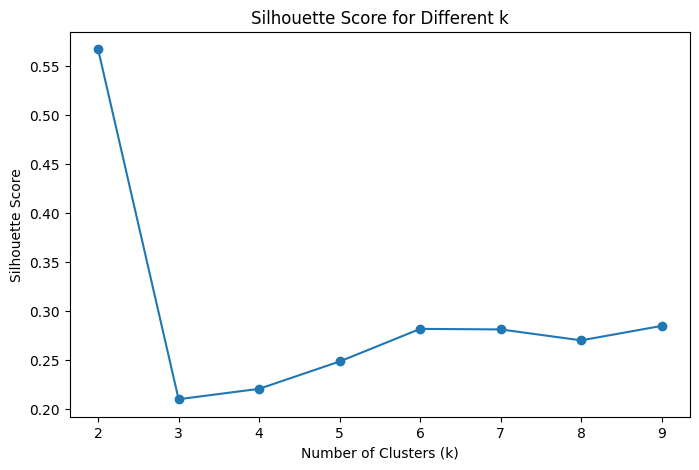

Best k based on silhouette: 2


In [73]:
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

print("Best k based on silhouette:",
      range(2,10)[np.argmax(silhouette_scores)])


### Silhouette Analysis Results

The silhouette analysis indicates that k = 2 produces the highest average silhouette score among the tested values. This suggests that dividing the data into two clusters provides the best balance between intra-cluster similarity and inter-cluster separation.


In [75]:
features = df[['latitude', 'longitude', 'year', 'hour', 'duration_seconds']]


In [78]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [79]:
optimal_k = range(2,10)[np.argmax(silhouette_scores)]

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

df['cluster'] = clusters


In [80]:
optimal_k = range(2,10)[np.argmax(silhouette_scores)]

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(features_scaled)

print("Final cluster distribution:")
print(df['cluster'].value_counts())


Final cluster distribution:
cluster
0    80269
1      450
Name: count, dtype: int64


In [81]:
cluster_summary = df.groupby('cluster').agg({
    'duration_seconds':'mean',
    'hour':'mean',
    'year':'mean',
    'latitude':'mean',
    'longitude':'mean'
})

print(cluster_summary)


         duration_seconds       hour         year  latitude  longitude
cluster                                                               
0              728.233021  15.664104  2003.795400  37.52312 -85.459685
1            29077.497778  14.128889  1999.446667  37.51939 -88.083624


## Cluster Visualisation Using PCA

this method was applied to project the high-dimensional feature space into two dimensions for visualisation purposes only. PCA was not used during clustering and does not influence the model outcome.


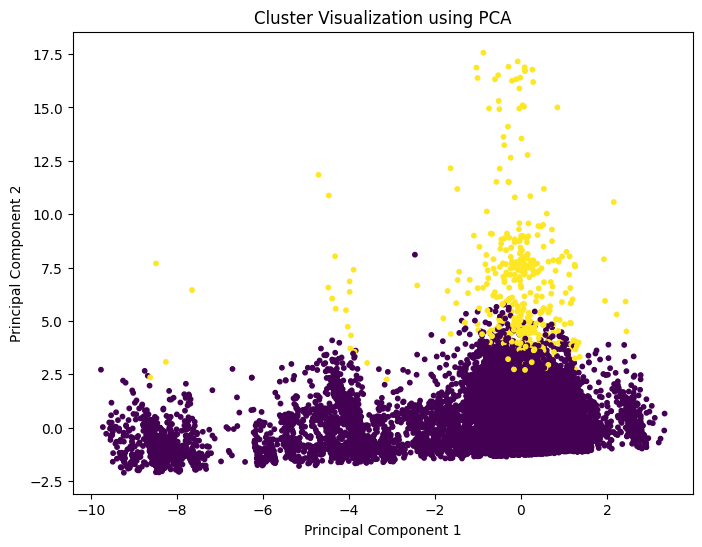

In [82]:
pca = PCA(n_components=2)
components = pca.fit_transform(features_scaled)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1],
            c=df['cluster'], cmap='viridis', s=10)
plt.title("Cluster Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


Although some overlap between clusters remains, a small separation is visible along the first principal component. This suggests that one or more dominant features contribute strongly to cluster differentiation.


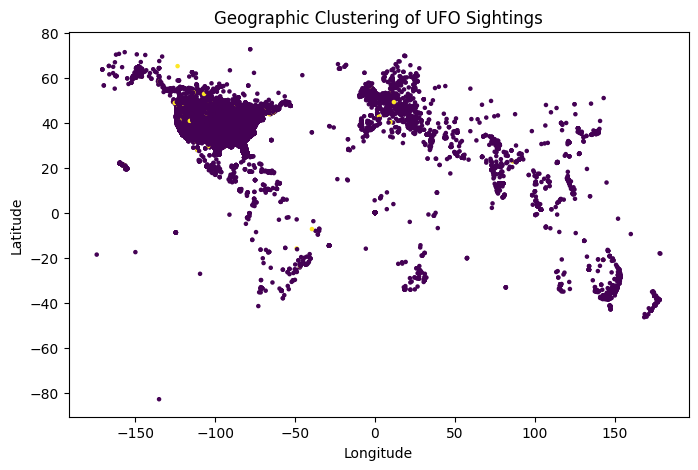

In [83]:
plt.figure(figsize=(8,5))
plt.scatter(df['longitude'], df['latitude'],
            c=df['cluster'], cmap='viridis', s=5)
plt.title("Geographic Clustering of UFO Sightings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [84]:
from scipy.stats import mannwhitneyu

cluster0 = df[df['cluster'] == 0]['duration_seconds']
cluster1 = df[df['cluster'] == 1]['duration_seconds']

u_stat, p_value = mannwhitneyu(cluster0, cluster1, alternative='two-sided')

u_stat, p_value


(121.0, 5.75419770596096e-295)